# Homework 5: TRPO and PPO

In this homework, you are required to implement the TRPO and PPO algorithms for the gym CartPole-v0 environment. In this problem, a pole is attached by an unactuated joint to a cart, which moves along a frictionless track. The pendulum is placed upright on the cart and the goal is to balance the pole by applying forces in the left and right direction on the cart. 

<div style="text-align: center;">
    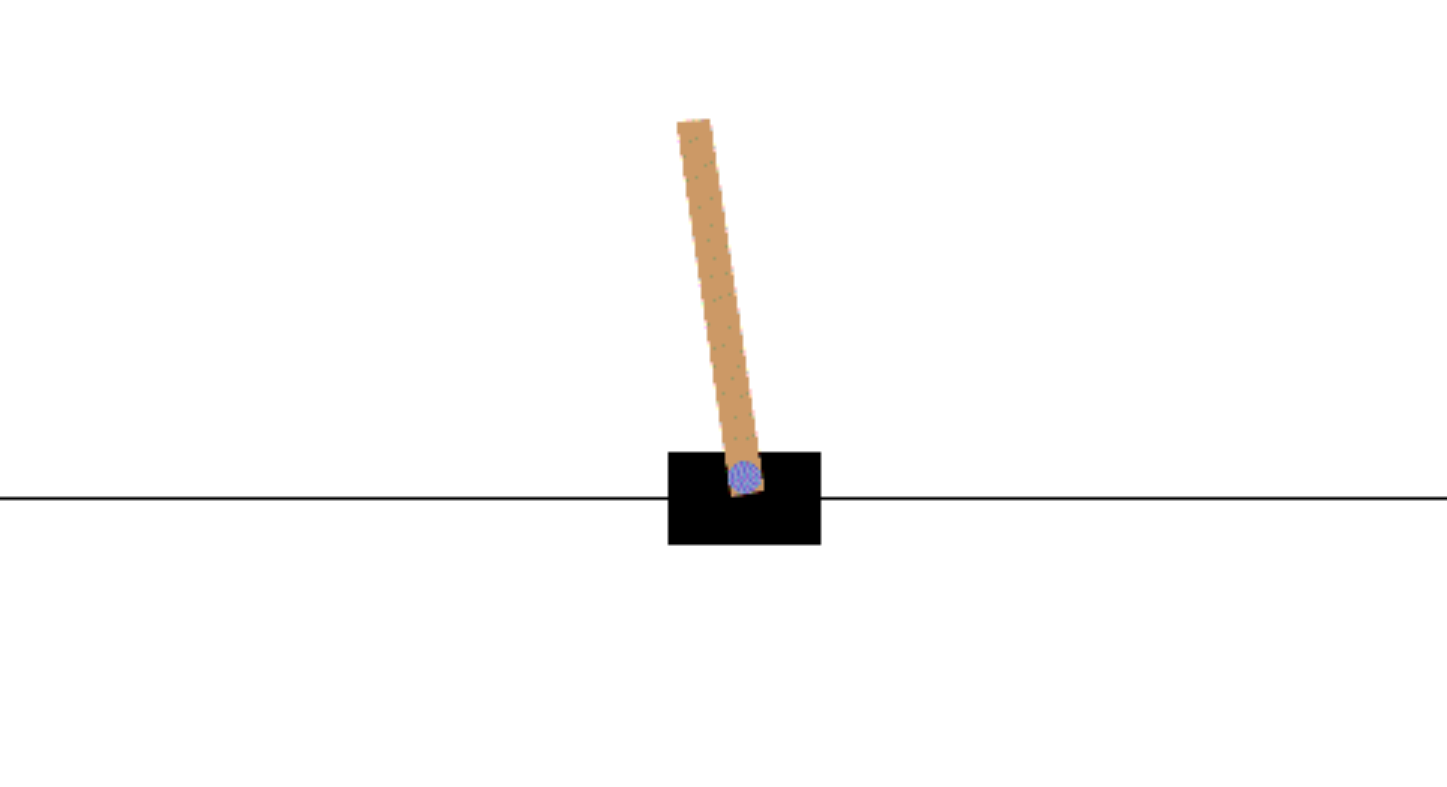
    <figcaption> Figure 1: The Cart Pole environment. </figcaption>
</div>

In this environment, the observation is a ndarray with shape $(4,)$ with the values corresponding to the following positions and velocities:

<div style="text-align: center; width: 100%;">
    <table style="margin: 0 auto;">
        <caption> Table 1: Observation space for the Cart Pole environment.</caption>
        <tr>
            <th>Num</th>
            <th>Observation</th>
            <th>Min</th>
            <th>Max</th>
        </tr>
        <tr>
            <td>0</td>
            <td>Cart Position</td>
            <td>-4.8</td>
            <td>4.8</td>
        </tr>
        <tr>
            <td>1</td>
            <td>Cart Velocity</td>
            <td>-Inf</td>
            <td>Inf</td>
        </tr>
        <tr>
            <td>2</td>
            <td>Pole Angle</td>
            <td>~-0.418 rad(-24&deg;)</td>
            <td>~0.418 rad(24&deg;)</td>
        </tr>
        <tr>
            <td>3</td>
            <td>Pole Angular Velocity</td>
            <td>-Inf</td>
            <td>Inf</td>
        </tr>
    </table>
</div>

The action space is a ndarray with shape $(1, )$ which can take values $0, 1$ indicating the direction of the fixed force the cart is pushed with:
- 0: push the cart to the left;
- 1: push the cart to the right.

Below are the utilities that we will need to implement the algorithms in this homework.

In [1]:
import copy
import torch
import numpy as np
import torch.nn.functional as F

class PolicyNet(torch.nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim):
        super(PolicyNet, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return F.softmax(self.fc2(x), dim=1)


class ValueNet(torch.nn.Module):
    def __init__(self, state_dim, hidden_dim):
        super(ValueNet, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)


## Section 1: Implementation of TRPO

Here you are required to implement the TRPO algorithm. Specifically, you are required to implement:
1. the `line_search()` function to find the best hyper-parameter for actor update (you may refer to [<a href="#ref1">1</a>, Appendix C]); 
2. the `policy_learn()` function to update actor policy (you may refer to [<a href="#ref1">1</a>, Section 6]);
3. the `update()` function to update the parameter of actor and critic (you may refer to [<a href="#ref1">1</a>, Section 6]).

In [15]:
class TRPO:
    def __init__(self, hidden_dim, state_space, action_space, lmbda,
                 kl_constraint, alpha, critic_lr, gamma, device):
        state_dim = state_space.shape[0]
        action_dim = action_space.n

        self.actor = PolicyNet(state_dim, hidden_dim, action_dim).to(device)
        self.critic = ValueNet(state_dim, hidden_dim).to(device)
        self.critic_optimizer = torch.optim.Adam(self.critic.parameters(),
                                                 lr=critic_lr)
        self.gamma = gamma
        self.lmbda = lmbda 
        self.kl_constraint = kl_constraint 
        self.alpha = alpha 
        self.device = device

    def take_action(self, state):
        state = torch.tensor([state], dtype=torch.float).to(self.device)
        probs = self.actor(state)
        action_dist = torch.distributions.Categorical(probs)
        action = action_dist.sample()
        return action.item()

    # The following function implement the trick in original TRPO paper, Appendix C.1 #
    def hessian_matrix_vector_product(self, states, old_action_dists, vector):

        new_action_dists = torch.distributions.Categorical(self.actor(states))
        kl = torch.mean(
            torch.distributions.kl.kl_divergence(old_action_dists,
                                                 new_action_dists))  
        kl_grad = torch.autograd.grad(kl,
                                      self.actor.parameters(),
                                      create_graph=True)
        kl_grad_vector = torch.cat([grad.view(-1) for grad in kl_grad])

        kl_grad_vector_product = torch.dot(kl_grad_vector, vector)
        grad2 = torch.autograd.grad(kl_grad_vector_product,
                                    self.actor.parameters())
        grad2_vector = torch.cat([grad.view(-1) for grad in grad2])
        return grad2_vector

    # The following function implement onjugate gradient algorithm in original TRPO paper, Appendix C to find search direction $s$ #

    def conjugate_gradient(self, grad, states, old_action_dists):  
        x = torch.zeros_like(grad)
        r = grad.clone()
        p = grad.clone()
        rdotr = torch.dot(r, r)
        for i in range(10):
            Hp = self.hessian_matrix_vector_product(states, old_action_dists,
                                                    p)
            alpha = rdotr / torch.dot(p, Hp)
            x += alpha * p
            r -= alpha * Hp
            new_rdotr = torch.dot(r, r)
            if new_rdotr < 1e-10:
                break
            beta = new_rdotr / rdotr
            p = r + beta * p
            rdotr = new_rdotr
        return x

    def compute_surrogate_obj(self, states, actions, advantage, old_log_probs,
                              actor):  
        log_probs = torch.log(actor(states).gather(1, actions))
        ratio = torch.exp(log_probs - old_log_probs)
        return torch.mean(ratio * advantage)

    def line_search(self, states, actions, advantage, old_log_probs,
                    old_action_dists, max_vec): 
        old_para = torch.nn.utils.convert_parameters.parameters_to_vector(
            self.actor.parameters())
        old_obj = self.compute_surrogate_obj(states, actions, advantage,
                                             old_log_probs, self.actor)
        for i in range(15): 
            coef = self.alpha**i
            new_para = old_para + coef * max_vec
            new_actor = copy.deepcopy(self.actor)

            """ ------------- Programming 1: implement the linear search to find best parameter for actor (you may refer to original TRPO paper, Appendix C) ------------- """
            
            """ YOUR CODE HERE """
            torch.nn.utils.vector_to_parameters(new_para, new_actor.parameters())
            new_obj = self.compute_surrogate_obj(states, actions, advantage, old_log_probs, new_actor)
            new_action_dists = torch.distributions.Categorical(new_actor(states))
            kl = torch.mean(torch.distributions.kl.kl_divergence(old_action_dists, new_action_dists))
            if kl < self.kl_constraint and new_obj > old_obj:
                return new_para
        return old_para
            
        """ ------------- Programming 1 ------------- """



    def policy_learn(self, states, actions, old_action_dists, old_log_probs,
                     advantage): 
        surrogate_obj = self.compute_surrogate_obj(states, actions, advantage,
                                                   old_log_probs, self.actor)
        grads = torch.autograd.grad(surrogate_obj, self.actor.parameters())

        """ ------------- Programming 2: implement the conjugate_gradient function, the linear search function, to update actor parameter (you may refer to original TRPO paper, Section 6) ------------- """
        
        """ YOUR CODE HERE """
        obj_grad = torch.cat([grad.view(-1) for grad in grads])
        descent_dir = self.conjugate_gradient(obj_grad, states, old_action_dists)
        Hd = self.hessian_matrix_vector_product(states, old_action_dists, descent_dir)
        max_coef = torch.sqrt(2 * self.kl_constraint / torch.dot(descent_dir, Hd) + 1e-8)
        new_para = self.line_search(states, actions, advantage, old_log_probs, old_action_dists, max_coef * descent_dir)
        torch.nn.utils.vector_to_parameters(new_para, self.actor.parameters())
        """ ------------- Programming 2 ------------- """

    def update(self, transition_dict):
        states = torch.tensor(transition_dict['states'],
                              dtype=torch.float).to(self.device)
        actions = torch.tensor(transition_dict['actions']).view(-1, 1).to(
            self.device)
        rewards = torch.tensor(transition_dict['rewards'],
                               dtype=torch.float).view(-1, 1).to(self.device)
        next_states = torch.tensor(transition_dict['next_states'],
                                   dtype=torch.float).to(self.device)
        dones = torch.tensor(transition_dict['dones'],
                             dtype=torch.float).view(-1, 1).to(self.device)
        
        """ ------------- Programming 3: Compute GAE and update the parameter of actor and critic ------------- """

        """ YOUR CODE HERE """
        td_target = rewards + self.gamma * (1 - dones) * self.critic(next_states)
        td_error = td_target - self.critic(states)
        advantage = torch.zeros_like(td_error)
        advantage[-1] = td_error[-1]
        for i in reversed(range(len(td_error) - 1)):
            advantage[i] = td_error[i] + self.gamma * self.lmbda * advantage[i + 1]
        advantage.to(self.device)
        old_action_dists = torch.distributions.Categorical(self.actor(states).detach())
        old_log_probs = torch.log(old_action_dists.probs.gather(1, actions)).detach()
        critic_loss = F.mse_loss(self.critic(states), td_target.detach())
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()        
        self.policy_learn(states, actions, old_action_dists, old_log_probs, advantage)

        """ ------------- Programming 3 ------------- """

## Section 2: Implementation of PPO

Here you are required to implement the PPO algorithm. Specifically, you are required to implement:

1. the `update()` function to update the parameter of actor and critic (you are required to implement the penalty version of PPO with fixed penalty coefficient $\beta$, and you can refer to [<a href="#ref1">2</a>, Section 4]).

In [55]:
class PPO:
    def __init__(self, state_dim, hidden_dim, action_dim, actor_lr, critic_lr,
                 lmbda, epochs, beta, gamma, device):
        self.actor = PolicyNet(state_dim, hidden_dim, action_dim).to(device)
        self.critic = ValueNet(state_dim, hidden_dim).to(device)
        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(),
                                                lr=actor_lr)
        self.critic_optimizer = torch.optim.Adam(self.critic.parameters(),
                                                 lr=critic_lr)
        self.gamma = gamma
        self.lmbda = lmbda  # The parameter used to compute advantage function
        self.epochs = epochs
        self.device = device
        self.beta = beta

    def take_action(self, state):
        state = torch.tensor([state], dtype=torch.float).to(self.device)
        probs = self.actor(state)
        action_dist = torch.distributions.Categorical(probs)
        action = action_dist.sample()
        return action.item()

    def update(self, transition_dict):
        states = torch.tensor(transition_dict['states'],
                              dtype=torch.float).to(self.device)
        actions = torch.tensor(transition_dict['actions']).view(-1, 1).to(
            self.device)
        rewards = torch.tensor(transition_dict['rewards'],
                               dtype=torch.float).view(-1, 1).to(self.device)
        next_states = torch.tensor(transition_dict['next_states'],
                                   dtype=torch.float).to(self.device)
        dones = torch.tensor(transition_dict['dones'],
                             dtype=torch.float).view(-1, 1).to(self.device)
        
        """ ------------- Programming 4: Compute Advantage Function ------------- """

        """ YOUR CODE HERE """
        td_target = rewards + self.gamma * (1 - dones) * self.critic(next_states)
        td_error = td_target - self.critic(states)
        td_error = td_error.detach()
        advantage = torch.zeros_like(td_error)
        advantage[-1] = td_error[-1]
        for i in reversed(range(len(td_error) - 1)):
            advantage[i] = td_error[i] + self.gamma * self.lmbda * advantage[i + 1]
        advantage.to(self.device)
        
        old_probs =self.actor(states).detach()
        old_log_probs = torch.log(old_probs.gather(1, actions))
        old_action_dist = torch.distributions.Categorical(old_probs)
        """ ------------- Programming 4 ------------- """

        for _ in range(self.epochs):

            """ ------------- Programming 5: Update the parameter of actor and critic (you may refer to original PPO paper) ------------- """
            
            """ YOUR CODE HERE """
            new_probs = self.actor(states)
            new_log_prob = torch.log(new_probs.gather(1, actions))
            ratio = torch.exp(new_log_prob - old_log_probs)
            
            new_action_dist = torch.distributions.Categorical(new_probs)
            kl_div = torch.distributions.kl.kl_divergence(old_action_dist, new_action_dist)

            actor_loss = torch.mean(-ratio * advantage + self.beta * kl_div)
            critic_loss =  torch.mean(F.mse_loss(self.critic(states), td_target.detach()))
            self.actor_optimizer.zero_grad()
            self.critic_optimizer.zero_grad() 
            actor_loss.backward()
            critic_loss.backward()
            self.actor_optimizer.step() 
            self.critic_optimizer.step()

            """ ------------- Programming 5 ------------- """


## Section 3: Evaluation and Discussions

kl constraint: 1e-06


Iteration 0:   0%|          | 0/50 [00:00<?, ?it/s]

Iteration 9: 100%|██████████| 50/50 [00:01<00:00, 29.95it/s, episode=500, return=56.100]


kl constraint: 1e-05


Iteration 9: 100%|██████████| 50/50 [00:04<00:00, 12.33it/s, episode=500, return=166.600]


kl constraint: 0.0001


Iteration 9: 100%|██████████| 50/50 [00:05<00:00,  9.34it/s, episode=500, return=200.000]


kl constraint: 0.001


Iteration 9: 100%|██████████| 50/50 [00:04<00:00, 11.77it/s, episode=500, return=147.700]


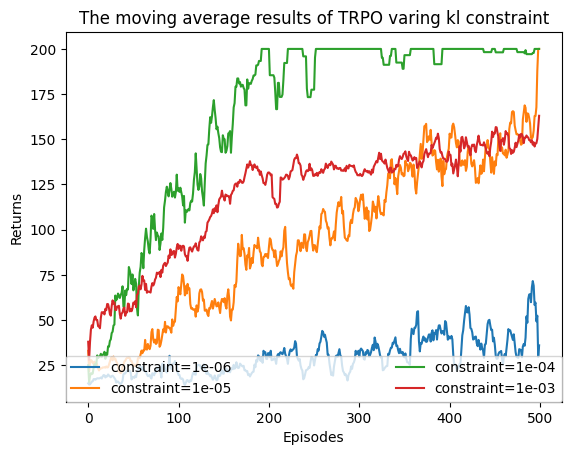

beta: 0


Iteration 9: 100%|██████████| 50/50 [00:01<00:00, 46.87it/s, episode=500, return=9.600]


beta: 10


Iteration 9: 100%|██████████| 50/50 [00:04<00:00, 10.24it/s, episode=500, return=200.000]


beta: 100


Iteration 9: 100%|██████████| 50/50 [00:04<00:00, 11.64it/s, episode=500, return=194.300]


beta: 1000


Iteration 9: 100%|██████████| 50/50 [00:04<00:00, 11.29it/s, episode=500, return=194.100]


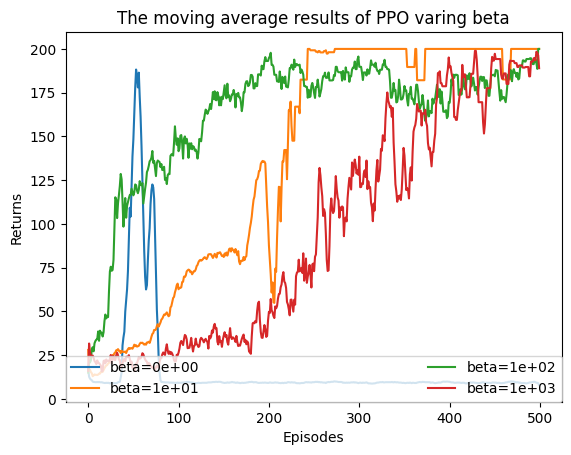

In [60]:
import gym
import time
import random
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

critic_lr = 1e-2
num_episodes = 500
hidden_dim = 128
gamma = 0.98  
lmbda = 0.95 # The parameter of Generalized Advantage Estimation (GAE)
epochs = 10
eps = 0.2
device = torch.device("cuda") if torch.cuda.is_available() else torch.device(
    "cpu")

# The parameters for TRPO
kl_constraint = 0.0005 # \delta in orginal TRPO paper
alpha = 0.5

#The parameters for PPO
actor_lr = 5e-3  # The actor learning rate only used by PPO


env_name = 'CartPole-v0'
env = gym.make(env_name)
env.seed(1)
torch.manual_seed(1)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

def moving_average(a, window_size):
    cumulative_sum = np.cumsum(np.insert(a, 0, 0)) 
    middle = (cumulative_sum[window_size:] - cumulative_sum[:-window_size]) / window_size
    r = np.arange(1, window_size-1, 2)
    begin = np.cumsum(a[:window_size-1])[::2] / r
    end = (np.cumsum(a[:-window_size:-1])[::2] / r)[::-1]
    return np.concatenate((begin, middle, end))

def train_on_policy_agent(env, agent, num_episodes):
    return_list = []
    update_timecost = []
    for i in range(10):
        with tqdm(total=int(num_episodes/10), desc='Iteration %d' % i) as pbar:
            for i_episode in range(int(num_episodes/10)):
                episode_return = 0
                transition_dict = {'states': [], 'actions': [], 'next_states': [], 'rewards': [], 'dones': []}
                state = env.reset()
                done = False
                while not done:
                    action = agent.take_action(state)
                    next_state, reward, done, _ = env.step(action)
                    transition_dict['states'].append(state)
                    transition_dict['actions'].append(action)
                    transition_dict['next_states'].append(next_state)
                    transition_dict['rewards'].append(reward)
                    transition_dict['dones'].append(done)
                    state = next_state
                    episode_return += reward
                return_list.append(episode_return)
                start_time = time.perf_counter()
                agent.update(transition_dict)
                end_time = time.perf_counter()
                update_timecost.append((end_time - start_time) / len(transition_dict['dones']))
                if (i_episode+1) % 10 == 0:
                    pbar.set_postfix({'episode': '%d' % (num_episodes/10 * i + i_episode+1), 'return': '%.3f' % np.mean(return_list[-10:])})
                pbar.update(1)
    cumu_time_cost = [sum(update_timecost[0:i+1]) for i in range(len(update_timecost))]
    return return_list, cumu_time_cost

def plot_vary_beta(episodes_list_PPO, return_list_PPO_beta, beta_list):
    plt.figure()
    for i in range(len(beta_list)):
        plt.plot(episodes_list_PPO,return_list_PPO_beta[i], label=f"beta={beta_list[i]:.0e}")
    plt.xlabel('Episodes')
    plt.ylabel('Returns')
    plt.legend(loc='lower right', ncol=2, mode="expand", borderaxespad=0.)
    plt.title('The moving average results of PPO varing beta'.format(env_name))
    plt.show()

def plot_vary_kl_constraint(episodes_list_TRPO, return_list_TRPO_constraint, kl_constraint_list):
    plt.figure()
    for i in range(len(kl_constraint_list)):
        plt.plot(episodes_list_TRPO,return_list_TRPO_constraint[i], label=f"constraint={kl_constraint_list[i]:.0e}")
    plt.xlabel('Episodes')
    plt.ylabel('Returns')
    plt.legend(loc='lower right', ncol=2, mode="expand", borderaxespad=0.)
    plt.title('The moving average results of TRPO varing kl constraint'.format(env_name))
    plt.show()


def plot_update_time(TRPO_episode_list, TRPO_update_time, TRPO_param_list, PPO_episode_list, PPO_update_time, PPO_param_list, TRPO_param, PPO_param):
    plt.figure()
    for i in range(len(TRPO_param_list)):
        if TRPO_param_list[i] == TRPO_param:
            plt.plot(TRPO_episode_list, TRPO_update_time[i], label=f" TRPO constraint={TRPO_param_list[i]:.0e}")
            break
    for i in range(len(PPO_param_list)):
        if PPO_param_list[i] == PPO_param:
            plt.plot(PPO_episode_list, PPO_update_time[i], label=f" PPO beta={PPO_param_list[i]:.0e}")
            break
    plt.xlabel('Episodes')
    plt.ylabel('Cumulative Average Update Time')
    plt.legend(loc='lower right', ncol=2, mode="expand", borderaxespad=0.)
    plt.title(f'The cumulative average update time of TRPO PPO with Their Best Performance Param')
    plt.show()

def set_seed():
    seed = 42
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed()
kl_constraint_list = [1e-6,1e-5, 1e-4,1e-3]
return_list_TRPO_constraint = []
time_TRPOs = []
for kl_constraint in kl_constraint_list:
    print("kl constraint: "+ str(kl_constraint))
    agent = TRPO(hidden_dim, env.observation_space, env.action_space, lmbda,
        kl_constraint, alpha, critic_lr, gamma, device)

    return_list_TRPO, time_TRPO = train_on_policy_agent(env, agent, num_episodes)
    time_TRPOs.append(time_TRPO)
    episodes_list_TRPO = list(range(len(return_list_TRPO)))
    mv_return_TRPO = moving_average(return_list_TRPO, 9)
    return_list_TRPO_constraint.append(mv_return_TRPO)
plot_vary_kl_constraint(episodes_list_TRPO, return_list_TRPO_constraint, kl_constraint_list)

set_seed()
beta_list = [0,10,100, 1000]
return_list_PPO_beta = []
time_PPOs = []
for beta in beta_list:
    print("beta: "+str(beta))
    agent = PPO(state_dim, hidden_dim, action_dim, actor_lr, critic_lr, lmbda,
            epochs, beta, gamma, device)

    return_list_PPO, time_PPO = train_on_policy_agent(env, agent, num_episodes)
    time_PPOs.append(time_PPO)
    episodes_list_PPO = list(range(len(return_list_PPO)))
    mv_return_PPO = moving_average(return_list_PPO, 9)
    return_list_PPO_beta.append(mv_return_PPO)
plot_vary_beta(episodes_list_PPO, return_list_PPO_beta, beta_list)


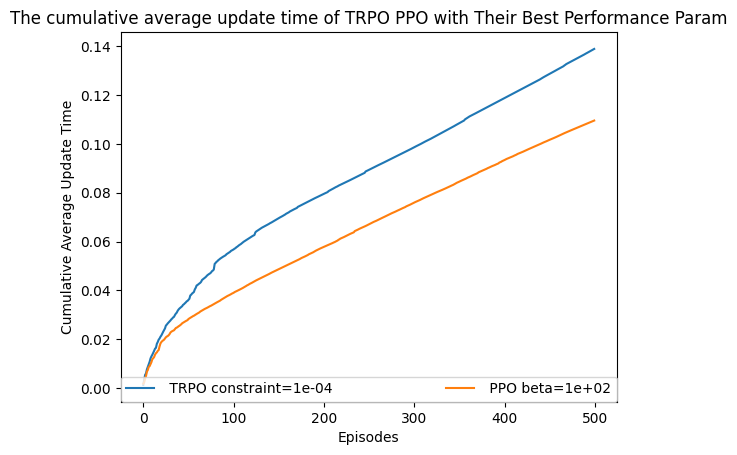

In [62]:
plot_update_time(
    episodes_list_TRPO, time_TRPOs, kl_constraint_list,
    episodes_list_PPO, time_PPOs, beta_list,
    TRPO_param=1e-4, # Please fill here the parameter with the best performance for TRPO above
    PPO_param=1e+2, # Please fill here the parameter with the best performance for PPO above
    )

In this section, please run your codes to show the performances of TRPO and PPO in the above environment and answer the following questions:

1. Compare the performance of TRPO algorithms with different values of trust region constraints, i.e., $\delta$ in <a href="#ref1">1</a>. Discuss the reason for this difference.

   - Larger trust regions allow for more significant updates to the policy, enabling it to explore more aggressively and optimize the policy more effectively. 

   - When $\delta$ is 1e-4 and 1e-3, the performance is much better than $\delta$ is 1e-5 and 1e-6, especially for 1e-6, which is likely strapped in the safe region.
  
   - $\delta = 1e-4$ beat the others. It has a balance in exploration and exploitation.

2. Compare the performance of PPO algorithms with different values of penalty coefficients in the KL-divergence term, i.e., $\beta$ in <a href="#ref1">2</a>. Discuss the reason for this difference.
   - : A lower or no 𝛽(0,10) means that there is little to no penalty for deviations from the old policy. This allows the policy to change more freely from one update to the next, which can lead to rapid learning but also high volatility and potential for drastic performance drops.
   - A higher 𝛽(100, 1000) significantly penalizes deviations in policy updates. It restricts the policy's ability to explore radically new strategies, which can slow learning but enhances stability in performance. 
   - 𝛽=10 offers a balance, leading to high and stable returns.
3. Are the impacts of parameter $\delta$ on TRPO algorithms and the impacts of parameter $\beta$ on PPO algorithms similar or not? Discuss the reason.
   - They are similar in restricting the action in a trust region near old policy, which ensures the policy does not change too drastically,
   - TPRO uses $\delta$ to represent the trust region, while PPO uses $\beta$ to penalize the deviations from the old policy.
4. Compare the update time cost for TRPO and PPO with their own parameters ($\delta$ or $\beta$) that shows the best performance. Which algorithm shows less time cost to update? Discuss the reason for your observation.
   -  PPO shows less time cost to update.
   -  PPO uses a penalty for KL-divergence, avoids the complex computations involved in solving the constrained optimization problem in TRPO.
   -  TRPO involvs multiple evaluations and adjustments per update

## References

<ol>
    <li id="ref1">J. John Schulman, Sergey Levine, Pieter Abbeel, Michael Jordan, and Philipp Moritz. Trust region policy optimization. In International conference on machine learning, pages 1889 1897. PMLR, 2015.</li>
    <li id="ref2">J. John Schulman, Filip Wolski, Prafulla Dhariwal, Alec Radford, and Oleg Klimov. Proximal policy optimization algorithms. arXiv preprint arXiv:1707.06347, 2017.</li>
</ol>